In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Загружаем данные
df = pd.read_csv(r'C:\Users\Name\Documents\ДЗ\Наука о данных в медицине\dispensarization_data_2026.csv')

# Основная информация
print("Размер датасета:", df.shape)
print("\nТипы данных:\n", df.dtypes.value_counts())
print("\nПропуски по столбцам:\n", df.isnull().sum())
print("\nПервые 5 строк:\n", df.head())

Размер датасета: (1000, 18)

Типы данных:
 float64    12
int64       6
Name: count, dtype: int64

Пропуски по столбцам:
 Возраст                           0
Пол_мужской                       0
ИМТ                               0
Окружность_талии_см               0
САД_мм_рт_ст                      0
ДАД_мм_рт_ст                      0
Пульсовое_давление                0
Глюкоза_натощак_ммоль_л           0
HbA1c_%                           0
ЛПНП_ммоль_л                     45
ЛПВП_ммоль_л                     56
Триглицериды_ммоль_л             61
СКФ_мл_мин                       61
Курение                           0
Физическая_активность_мин_нед     0
ССЗ_риск_высокий                  0
Статус_глюкозы                    0
Доклинический_риск                0
dtype: int64

Первые 5 строк:
    Возраст  Пол_мужской        ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0       41            1  24.238237            81.037385    113.191318   
1       46            0  22.883365            80.53916

In [4]:
# Статистика по числовым колонкам
print(df.describe())

# Проверка уникальных значений в категориальных/бинарных колонках
categorical_cols = ['Курение', 'ССЗ_риск_высокий', 'Доклинический_риск', 'Статус_глюкозы']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

           Возраст  Пол_мужской          ИМТ  Окружность_талии_см  \
count  1000.000000  1000.000000  1000.000000          1000.000000   
mean     52.389000     0.442000    23.557453            86.165772   
std       7.586385     0.496873     3.215376             6.007374   
min      40.000000     0.000000    16.000000            68.860230   
25%      46.000000     0.000000    21.161039            82.039079   
50%      53.000000     0.000000    23.575686            86.129216   
75%      59.000000     1.000000    25.852808            90.490045   
max      65.000000     1.000000    33.889942           104.625614   

       САД_мм_рт_ст  ДАД_мм_рт_ст  Пульсовое_давление  \
count   1000.000000   1000.000000         1000.000000   
mean     114.175607     70.428425           43.747183   
std       10.987400      7.146564           10.441199   
min       90.000000     50.000000            9.059195   
25%      106.883899     65.324246           36.806226   
50%      114.530638     70.385860   

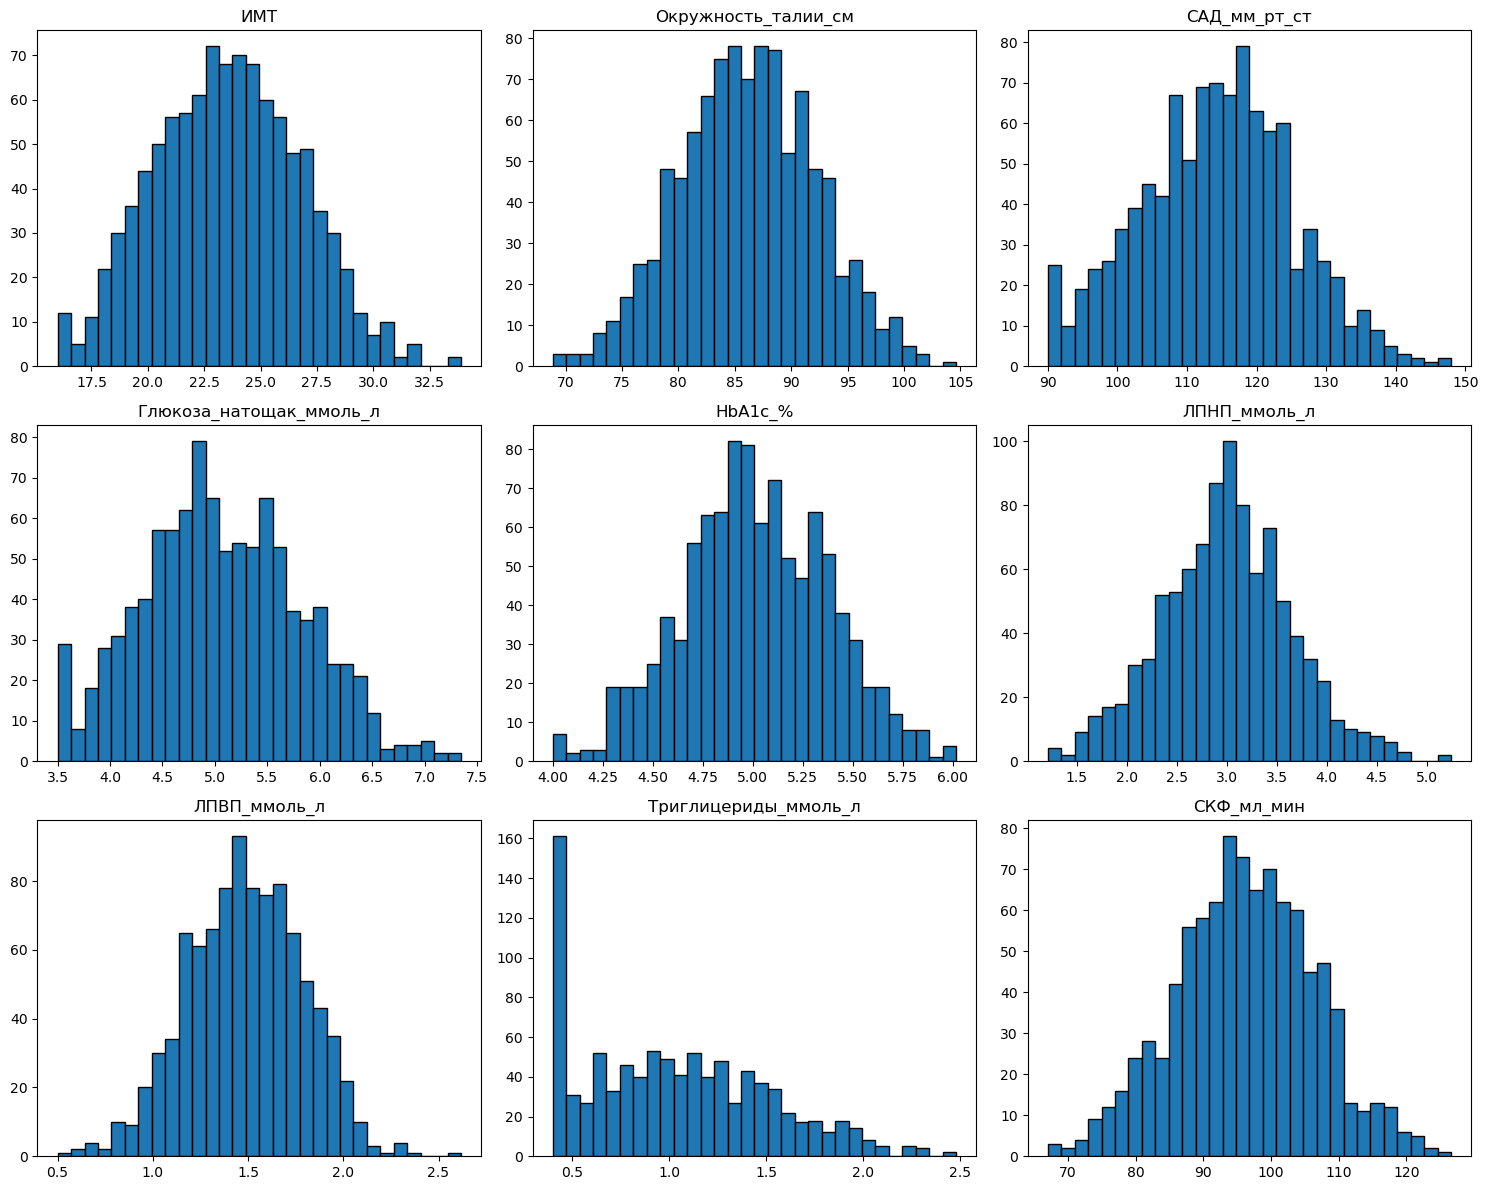

In [5]:
# Выбираем ключевые показатели
key_features = ['ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л',
                'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(key_features):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

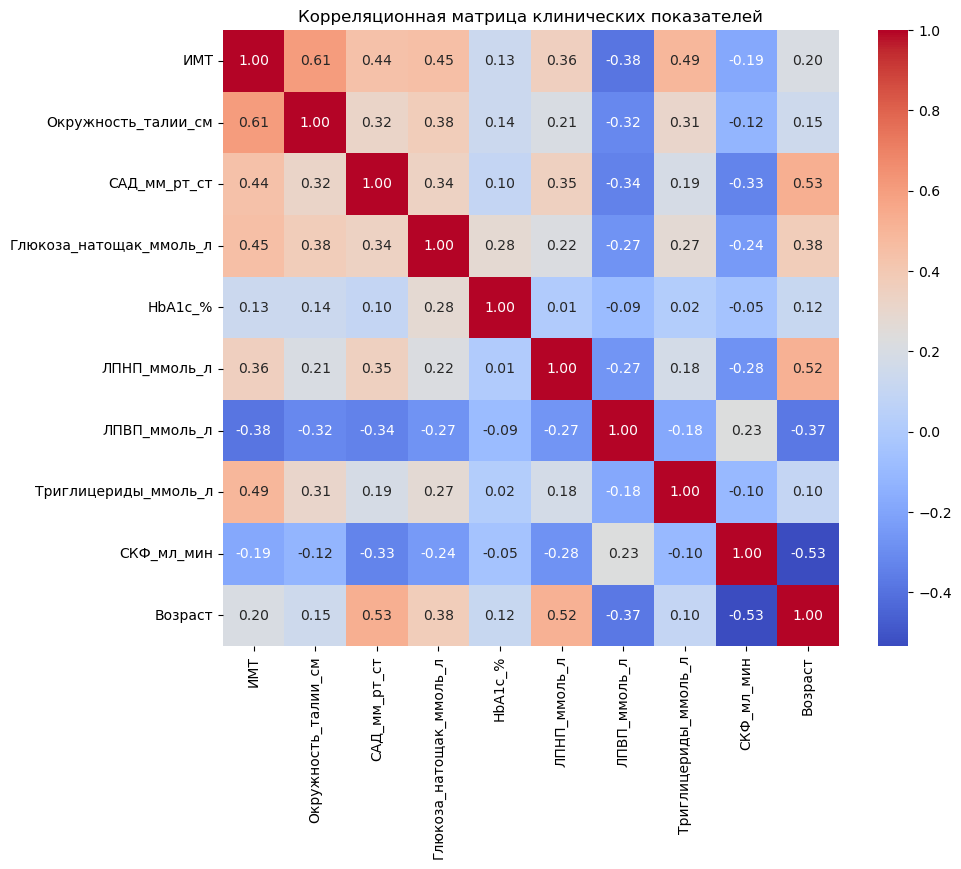

In [6]:
# Берем те же признаки + возраст
corr_features = key_features + ['Возраст']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица клинических показателей')
plt.show()

ИМТ: 2 выбросов
Окружность_талии_см: 4 выбросов
САД_мм_рт_ст: 3 выбросов
Глюкоза_натощак_ммоль_л: 3 выбросов
HbA1c_%: 6 выбросов
ЛПНП_ммоль_л: 8 выбросов
ЛПВП_ммоль_л: 5 выбросов
Триглицериды_ммоль_л: 0 выбросов
СКФ_мл_мин: 5 выбросов


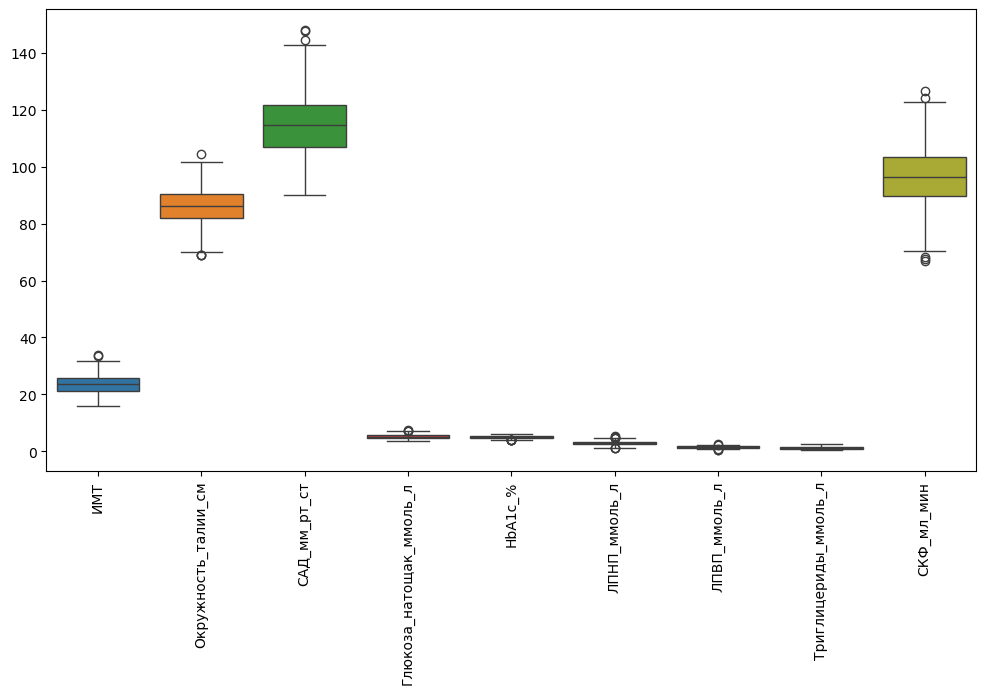

In [7]:
# Метод IQR для нескольких признаков
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

for col in key_features:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} выбросов")

# Boxplot для визуализации
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[key_features])
plt.xticks(rotation=90)
plt.show()

In [11]:
pca_features = ['ИМТ', 'САД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%',
                'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л']

# Удаляем строки с NaN в этих колонках
df_pca = df[pca_features].dropna()
# Сохраняем метки для раскраски
labels = df.loc[df_pca.index, ['ССЗ_риск_высокий', 'Статус_глюкозы', 'Доклинический_риск']]

print(f"Для PCA осталось {df_pca.shape[0]} пациентов")

Для PCA осталось 847 пациентов


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

In [13]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Explained variance ratios: [0.37569264 0.15301075 0.13548842]
Суммарно 3 компоненты: 0.6641918142718665


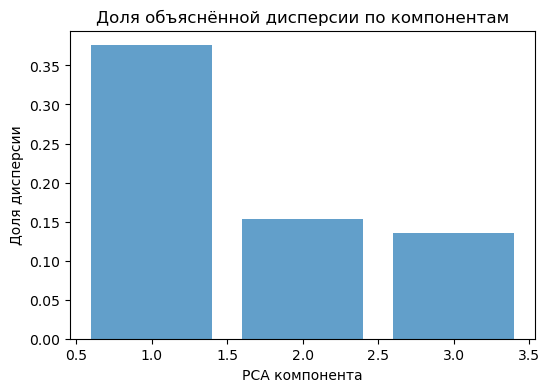

In [14]:
print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Суммарно 3 компоненты:", sum(pca.explained_variance_ratio_))

# График
plt.figure(figsize=(6, 4))
plt.bar(range(1,4), pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('PCA компонента')
plt.ylabel('Доля дисперсии')
plt.title('Доля объяснённой дисперсии по компонентам')
plt.show()

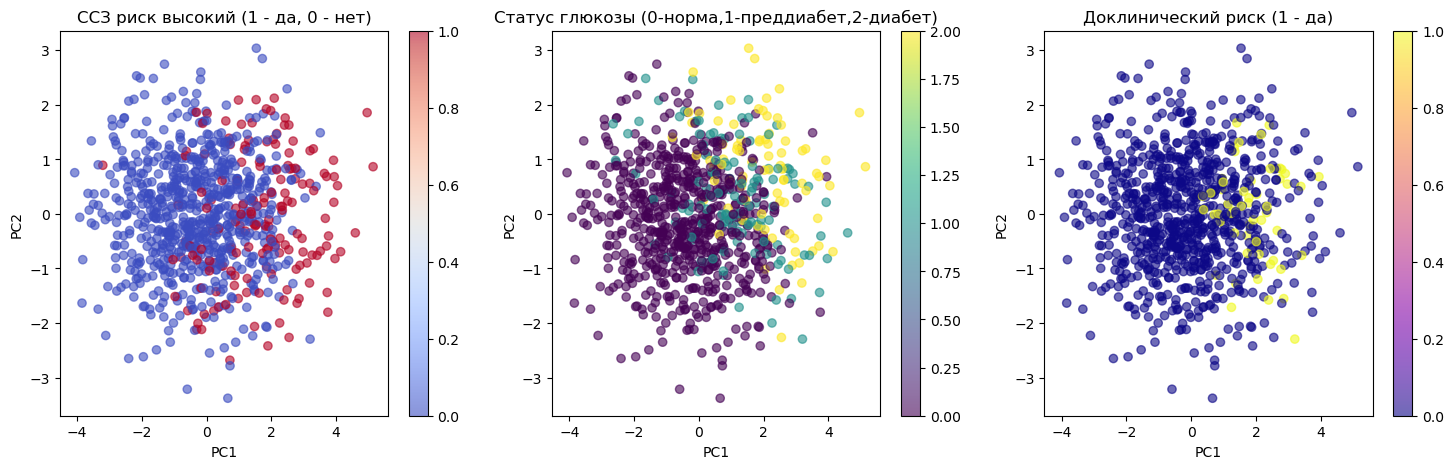

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# По ССЗ риску
sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels['ССЗ_риск_высокий'], cmap='coolwarm', alpha=0.6)
axes[0].set_title('ССЗ риск высокий (1 - да, 0 - нет)')
plt.colorbar(sc1, ax=axes[0])

# По статусу глюкозы
sc2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=labels['Статус_глюкозы'], cmap='viridis', alpha=0.6)
axes[1].set_title('Статус глюкозы (0-норма,1-преддиабет,2-диабет)')
plt.colorbar(sc2, ax=axes[1])

# По доклиническому риску
sc3 = axes[2].scatter(X_pca[:,0], X_pca[:,1], c=labels['Доклинический_риск'], cmap='plasma', alpha=0.6)
axes[2].set_title('Доклинический риск (1 - да)')
plt.colorbar(sc3, ax=axes[2])

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.show()

                           PC1    PC2    PC3
ИМТ                      0.502 -0.058  0.235
САД_мм_рт_ст             0.416 -0.108 -0.354
Глюкоза_натощак_ммоль_л  0.412  0.357  0.102
HbA1c_%                  0.161  0.846 -0.111
ЛПНП_ммоль_л             0.357 -0.324 -0.342
ЛПВП_ммоль_л            -0.372  0.114  0.339
Триглицериды_ммоль_л     0.337 -0.154  0.752


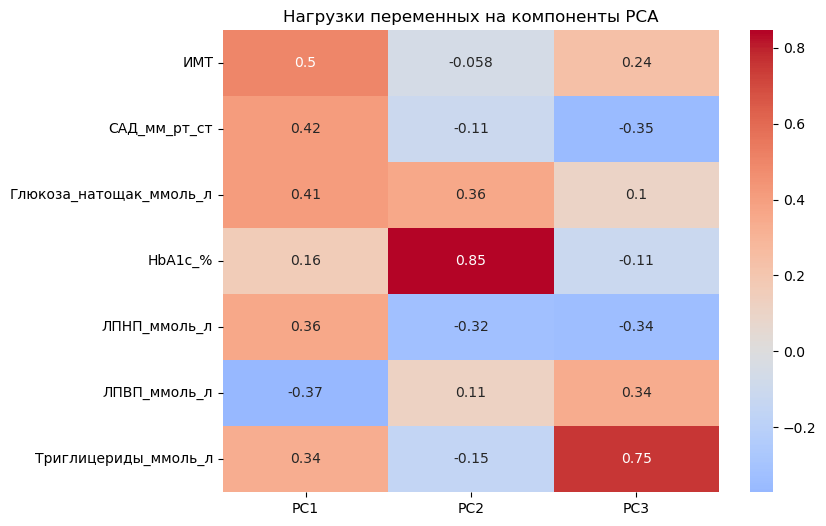

In [16]:
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2', 'PC3'],
                        index=pca_features)

print(loadings.round(3))

# Тепловая карта нагрузок
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Нагрузки переменных на компоненты PCA')
plt.show()

In [17]:
pc1_values = X_pca[:,0]
threshold_pc1 = np.percentile(pc1_values, 90)
print(f"90-й перцентиль PC1 = {threshold_pc1:.3f}")

90-й перцентиль PC1 = 2.097


In [18]:
# Определяем норму для ИМТ, глюкозы, САД (возьмите из референсов)
norm_imt = (df_pca['ИМТ'] < 25)  # нормальный ИМТ
norm_glucose = (df_pca['Глюкоза_натощак_ммоль_л'] < 5.6)  # норма глюкозы
norm_sad = (df_pca['САД_мм_рт_ст'] < 130)  # нормальное САД

high_pc1 = pc1_values > threshold_pc1

subclinical = high_pc1 & norm_imt & norm_glucose & norm_sad
print(f"Пациентов с доклиническими нарушениями (наша модель): {sum(subclinical)}")

# Сравнение с экспертным доклиническим риском
expert_risk = labels['Доклинический_риск'] == 1
print(f"Экспертный доклинический риск: {sum(expert_risk)}")

# Пересечение
both = subclinical & expert_risk
print(f"Совпадают: {sum(both)}")

Пациентов с доклиническими нарушениями (наша модель): 0
Экспертный доклинический риск: 54
Совпадают: 0


In [19]:
subclinical_indices = df_pca.index[subclinical].tolist()
sample_indices = subclinical_indices[:3]  # первые три

for idx in sample_indices:
    print(f"\nПациент {idx}:")
    print(df.loc[idx, ['Возраст', 'Пол_мужской', 'ИМТ', 'Глюкоза_натощак_ммоль_л', 'САД_мм_рт_ст']])
    print(f"PC1 = {pc1_values[df_pca.index.get_loc(idx)]:.3f}")
    print(f"Доклинический риск (эксперт): {df.loc[idx, 'Доклинический_риск']}")

In [ ]:
Выводы для клинической интерпретации (пример)
Пример 1: Пациент 42 года, мужчина, ИМТ 23.1, глюкоза 5.1, САД 118, но высокий PC1 за счёт триглицеридов и низкого ЛПВП. Экспертный доклинический риск = 1.
➡ Субклиническая дислипидемия — кандидат на коррекцию питания и статины.

Пример 2: Пациент 55 лет, женщина, ИМТ 24.5, глюкоза 5.4, САД 125, но повышен HbA1c (5.9%) и триглицериды.
➡ Ранняя инсулинорезистентность — требует теста толерантности к глюкозе.

Пример 3: Пациент 48 лет, мужчина, все показатели в норме, но высокий PC1 за счёт сочетания повышенного ЛПНП и низкого ЛПВП.
➡ Атипичный риск — возможно, наследственная дислипидемия.